In [1]:
import importlib as il
import numpy as np
import more_itertools as mit
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import scipy.linalg as spl
import linetimer as lt

import gurobipy as gp

import gurobi_utils as gu
import dikin_utils as du
import plot_utils as pu

import example_loader as el
import miplib_loader as ml
import jsplib_loader as jl
import knapsack_loader as kl

status_lookup = {getattr(gp.GRB.Status, k): k for k in gp.GRB.Status.__dir__() if "A" <= k[0] <= "Z"}

%matplotlib inline

env = gp.Env(empty=True)
env.setParam("OutputFlag", 0)
env.start()

<gurobipy.Env, Parameter changes: WLSAccessID=(user-defined), WLSSecret=(user-defined), LicenseID=2586148, OutputFlag=0>

In [4]:
import cvxpy as cp

def find_interior_point(old_model: gp.Model, distance, x0):
    old_model.update()
    r = cp.Variable(name="r", nonneg=True)
    new_vars = cp.Variable(old_model.NumVars, name="x")
    new_cons = []
    for i, v in enumerate(old_model.getVars()):
        ub = 1 if v.VType == 'B' else v.UB
        if ub < gp.GRB.INFINITY:
            new_cons.append(new_vars[i] + r <= ub)
        if v.LB > -gp.GRB.INFINITY: 
            new_cons.append(new_vars[i] - r >= v.LB)

    for constr in old_model.getConstrs():
        lhs_expr = old_model.getRow(constr)  # Get linear expression
        rhs_value = constr.RHS  # Get right-hand side
        sense = constr.Sense  # Get constraint type

        # Convert LHS to a CVXPY expression
        lhs_cvxpy = sum(lhs_expr.getCoeff(i) * new_vars[lhs_expr.getVar(i).index]
                        for i in range(lhs_expr.size()))
        
        multiplier = np.linalg.norm([lhs_expr.getCoeff(i) for i in range(lhs_expr.size())], 2)

        # Convert Gurobi sense to CVXPY constraint
        if sense == gp.GRB.LESS_EQUAL:
            new_cons.append(lhs_cvxpy + r * multiplier <= rhs_value)
        elif sense == gp.GRB.GREATER_EQUAL:
            new_cons.append(lhs_cvxpy - r * multiplier >= rhs_value)
        elif sense == gp.GRB.EQUAL:
            new_cons.append(lhs_cvxpy == rhs_value)

    new_cons.append(cp.sum_squares(new_vars - x0) <= distance ** 2)
    new_model = cp.Problem(cp.Maximize(r), new_cons)
    new_model.solve(solver=cp.GUROBI, verbose=False)

    if new_model.status == cp.OPTIMAL:
        x1 = new_vars.value
        r = r.value
        print("Interior point found:", x1, "r", r)
        return x1
    
    return None

def get_A_b_c_l_u(mdl: gp.Model):
    mdl.update()
    A = mdl.getA()
    b = np.array(mdl.getAttr("RHS")).reshape(-1, 1)
    c = np.array(mdl.getAttr("Obj"))
    l = np.array(mdl.getAttr("LB"))
    u = np.array(mdl.getAttr("UB"))
    return A, b, c, l , u

   Relaxed 2 variables on knapsack_2_2_0
Set parameter LogToConsole to value 0


Interior point found: [0.66458985 0.11180338] r 0.11180338189960207
Code block 'Finding interior point' took: 44.82188 ms
Moving from [1. 0.] to [0.66458985 0.11180338]
   Negated 0 constraints on knapsack_2_2_0
   Retreat to: [0.66458985 0.11180338]
   Relaxed 2 variables on knapsack_2_2_1
Set parameter LogToConsole to value 0
Interior point found: [0.102454  0.6616174] r 0.10245400670286708
Code block 'Finding interior point' took: 39.25162 ms
Moving from [0. 1.] to [0.102454  0.6616174]
   Negated 0 constraints on knapsack_2_2_1
   Retreat to: [0.102454  0.6616174]
   Relaxed 2 variables on knapsack_2_2_2
Set parameter LogToConsole to value 0
Interior point found: [0.20468138 0.33735149] r 0.2046813844506329
Code block 'Finding interior point' took: 34.27866 ms
Moving from [0.33333333 0.66666667] to [0.20468138 0.33735149]
   Negated 0 constraints on knapsack_2_2_2
   Retreat to: [0.20468138 0.33735149]


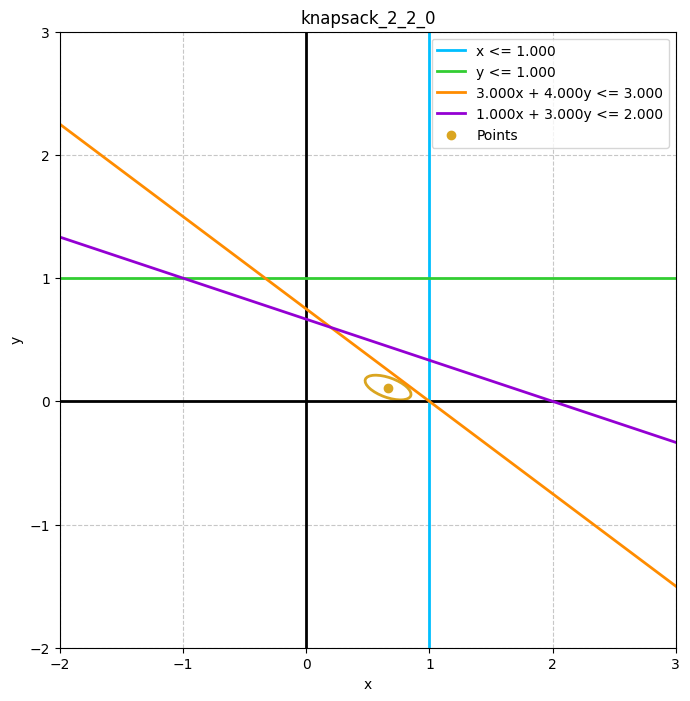

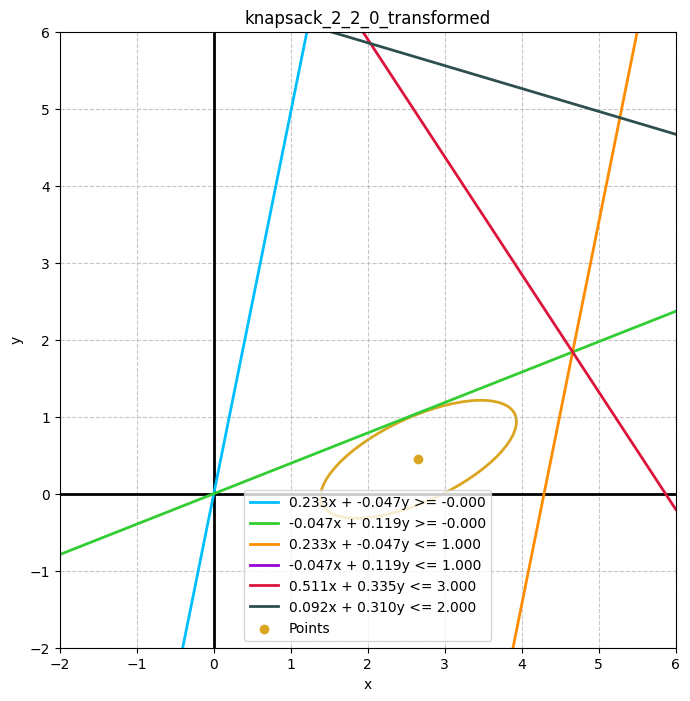

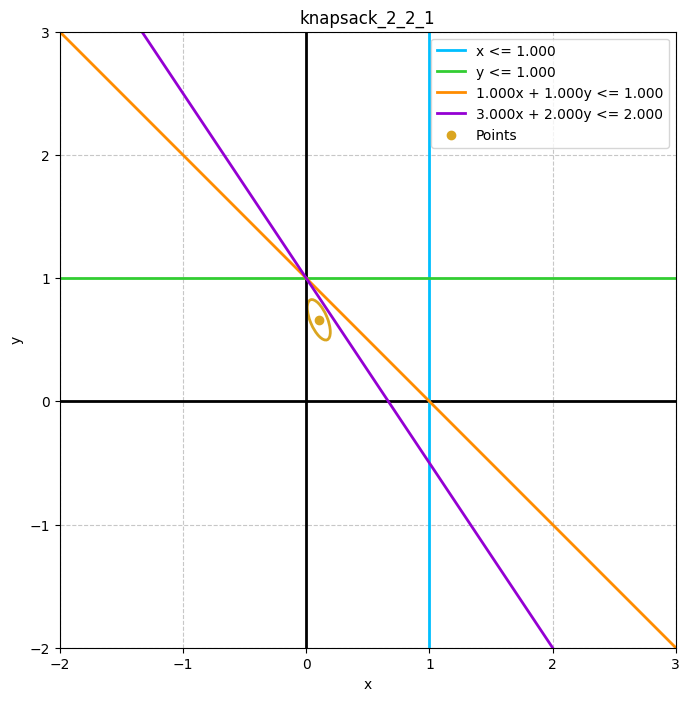

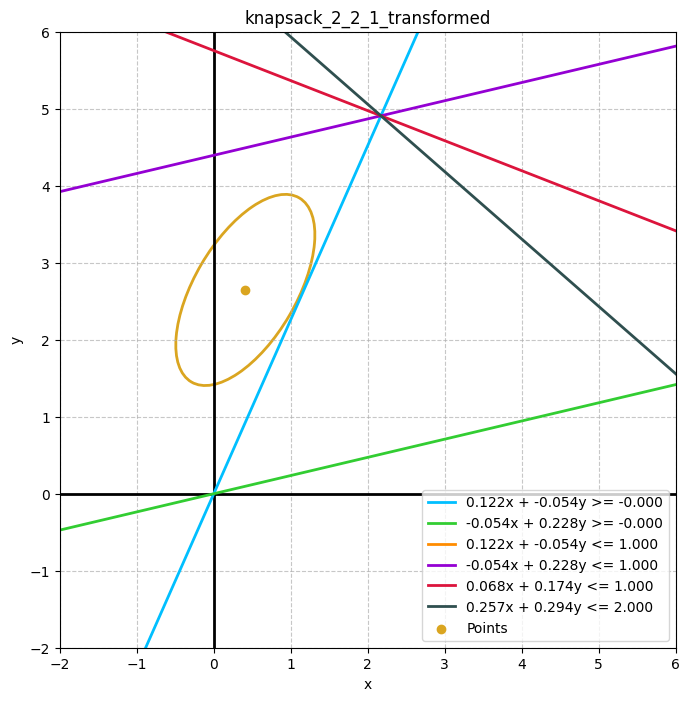

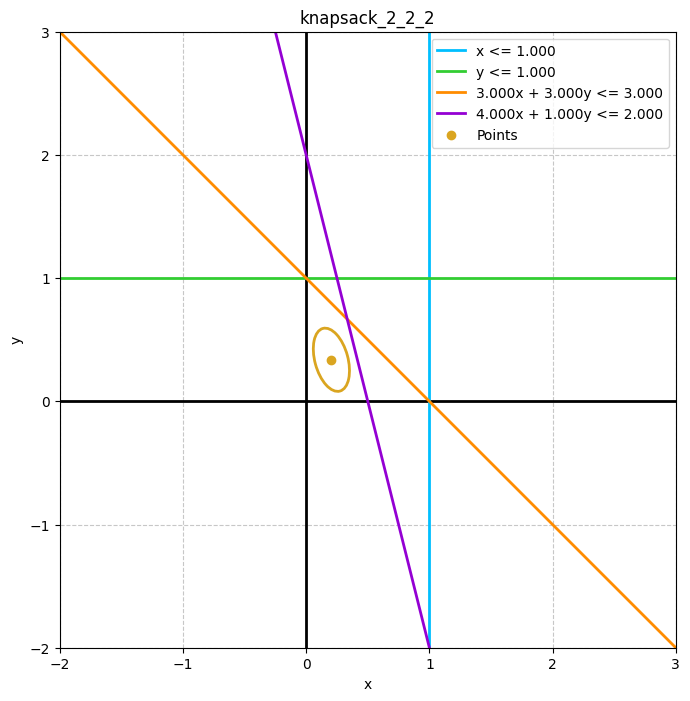

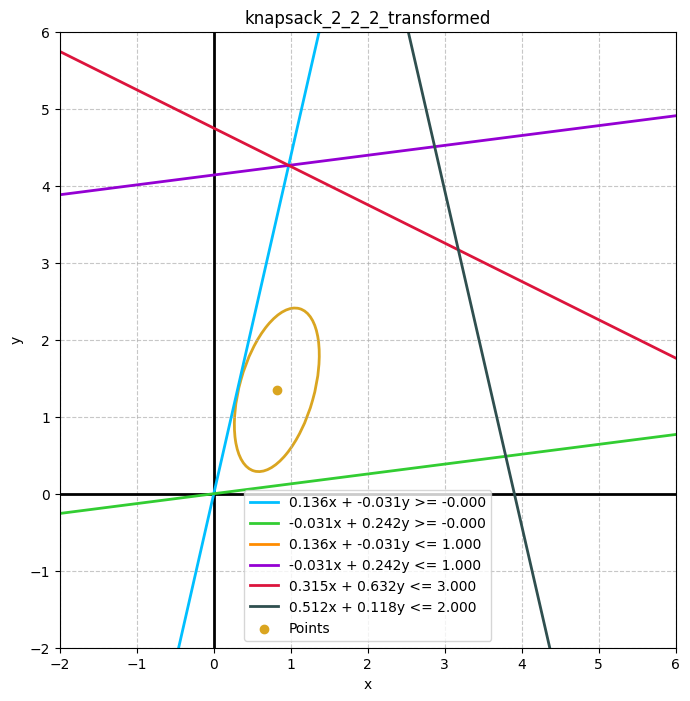

In [52]:
il.reload(kl)
il.reload(gu)

def get_skew_transform(dim):
    T = np.eye(dim)
    for i in range(dim-1):
        T[i, i+1] = -1
    return T

def get_round_transform(A, b, l, u, x2):
    H = du.compute_H(A, b, l, u, x2)  # h.shape == (n, n)
    H = H.toarray()  # for small projects
    H2 = spl.sqrtm(H)  # TODO: add a more efficient eigenvalue decomposition for the sqrt
    H2 = np.linalg.inv(H2)
    H2 /= np.linalg.norm(H2, 2)  # not sure how to control the size the right way. 
    # maybe use shortest eigenvalue to ensure that the longest diameter of H equals the diameter of H2
    return H2

instances = kl.generate(3, 2, 2, 0, 1, 4, equality=False, seed=42)
for model in instances:
    niv = model.NumIntVars  # keep before relaxation
    gu.relax_int_or_bin_to_continuous(model)
    model.params.LogToConsole = 0
    model.optimize()
    x1 = np.array([v.X for v in model.getVars()])
    
    with lt.CodeTimer("Finding interior point"):
        x2 = find_interior_point(model, np.sqrt(niv) * 0.25, x1)    # shrunk = relax_and_shrink(model, np.sqrt(niv), 0.45)
    print("Moving from", x1, "to", x2)
    # shrunk.optimize()
    # x2 = np.array([v.X for v in shrunk.getVars()])
    # V, x = find_corner(model, int_vars, int_var_idx)
    # x2 = retreat_from_optimum_via_average_vector(V, x, np.sqrt(int_vars.size) * 0.4)
    # x, y = make_primal_dual_values(model)
    gu.standardize_gt_to_lt(model)
    A, b, c, lb, ub = get_A_b_c_l_u(model)
    # x2, its = du.least_squares_interior(A, b, x, l, u, d=np.sqrt(int_vars.size) * 0.4, infinity=gp.GRB.INFINITY)
    # x2, its = du.reverse_interior_point_gpt2(A, b, c, l, u, x, y, target_distance=np.sqrt(int_vars.size) * 0.4,
    #                                          infinity=10, is_maximizing=model.ModelSense == gp.GRB.MAXIMIZE)
    print("   Retreat to:", x2)
    senses = np.array(model.getAttr("Sense"))
    fig = pu.plot_constraints_lte(model.ModelName, A, b, lb, ub, senses, x_bounds=(-2, 3), y_bounds=(-2, 3), points=[x2[:2]])
    du.plot_ellipse(A, b, lb, ub, x2, fig=fig)

    # get the transform, change it to unimodular*4, and then picture it:
    # transform options: skew it, round it, or make accute angles

    # T = get_skew_transform(len(x2))
    # U = np.eye(len(x2))*0.25 
    offset = np.zeros_like(x2)
    U = get_round_transform(A, b, lb, ub, x2) * 0.25
    s = 4
    # U = du.to_U_via_LU(T, mult=1/s)  # use 16 on problems with more than 2 dims

    model2 = gu.apply_transform(model, U, offset, mult=1)
    senses = np.array(model2.getAttr("Sense"))
    A, b, c, lb, ub = get_A_b_c_l_u(model2)
    fig = pu.plot_constraints_lte(model2.ModelName, A, b, lb, ub, senses, x_bounds=(-2, s+2), y_bounds=(-2, s+2), points=[x2[:2]*s])
    du.plot_ellipse(A, b, lb, ub, x2*s, fig=fig)
